# Project 6: Image Classification with Deep Learning

This project introduces us to deep learning. The deep learning process is a huge leap forward in data science and the field is less than 15 years old. The processing is significantly different from our previous projects so you will basically be provided a walkthrough document delineating the steps - much like Project 1. Deep learning is fascinating and I just want you to go through the process so you can appreciate its power.

The data collection portion of deep learning projects is a rather complex task. In other words, there is no CSV file that we can load to serve as our training data. Constructing a training data set is a rather large undertaking. We have imported all the training images (took hours) and I will show you how you can load the training data through the "pickle" process.

There are three files in this data set:
- [the feature set](https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/X.pickle), i.e. images of dogs and cats ( mostly )
- [the target set](https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/y.pickle), i.e. the label (0/1) that something is a dog or cat ( mostly )
- [a test image](https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/dog.jpg)

This project will classify new, unseen images of cats and dogs. This was one of the first big success stories of deep learning and we will go through the process of building a learning algorithm that will do this task. Distinguishing a picture of a cat from a picture of a dog is easy for humans to do, but had been notoriously difficult to get a computer learning to perform well on the task. Deep learning solved that.

The same data sets as above, but you can copy the links by viewing the markdown directly to bypass Google Colab's annoying "You are leaving Colab" link.

https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/X.pickle

https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/y.pickle

https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/dog.jpg

## AI Assistance Statement


This notebook was developed with the assistance of AI-based tools used as a reference for Python syntax, workflow organization, and debugging support. AI helped identify issues related to missing values, dataset preparation, and proper sequencing of machine learning steps such as data cleaning, model training, and cross-validation. All code included in this notebook was reviewed, executed, and validated to ensure it performs the intended analysis, and I maintained responsibility for understanding the modeling process and interpreting the results.

In [1]:
import pandas as pd


In [2]:
images_url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/X.pickle"
images_url


'https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/X.pickle'

In [3]:
image_array = pd.read_pickle( images_url )
type(image_array)


numpy.ndarray

In [4]:
image_array.shape


(24946, 100, 100, 1)

In [5]:
target_url = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/y.pickle"
target_url


'https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/y.pickle'

In [6]:
target = pd.read_pickle( target_url )
type(target)


list

## Building the deep learning model

The cells above just *loaded* the data. From here we (1) get the data into the right shape, (2) build a small convolutional neural network, (3) train it, and (4) hand it the unseen `dog.jpg` to classify. Each code cell is commented so it still makes sense six months from now.

In [7]:
# Bring in the deep learning toolkit plus our usual numeric/plotting helpers.
# WHY: TensorFlow/Keras gives us ready-made neural-network building blocks
#      (layers, models, training loop) so we never hand-code the calculus.
#      Colab ships TensorFlow pre-installed, so there is usually nothing to
#      pip install here.
# EXPECT: a printed TensorFlow version string, e.g. "TF version: 2.x.x".
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout

print("TF version:", tf.__version__)

TF version: 2.20.0


In [8]:
# Look at the target labels before doing anything else.
# WHY: cat-vs-dog is a BINARY problem, so the labels should only be 0 and 1.
#      Confirming that drives our loss-function choice (binary_crossentropy)
#      and a roughly even count tells us the classes are not badly imbalanced.
# EXPECT: the unique values [0 1] and a count for each class.
target = np.array(target)            # make sure it is a NumPy array, not a list
print("label values present:", np.unique(target))
print("count per label:", np.bincount(target))

label values present: [0 1]
count per label: [12470 12476]


In [9]:
# Scale the pixel values from the 0-255 range down to 0-1.
# WHY: neural networks train faster and more stably when their inputs are
#      small. Dividing by the largest possible pixel value (255) is the
#      standard way to rescale image data.
# NOTE: we store the result in X and leave the original image_array untouched,
#       in case we want to re-inspect the raw pixels later.
PIXEL_MAX = 255.0                    # named constant instead of a bare 255
X = np.array(image_array) / PIXEL_MAX
y = target

print("feature shape:", X.shape)    # expect (N, H, W, C), e.g. (N, 50, 50, 1)
print("min pixel:", round(float(X.min()), 3))
print("max pixel:", round(float(X.max()), 3))

feature shape: (24946, 100, 100, 1)
min pixel: 0.0
max pixel: 1.0


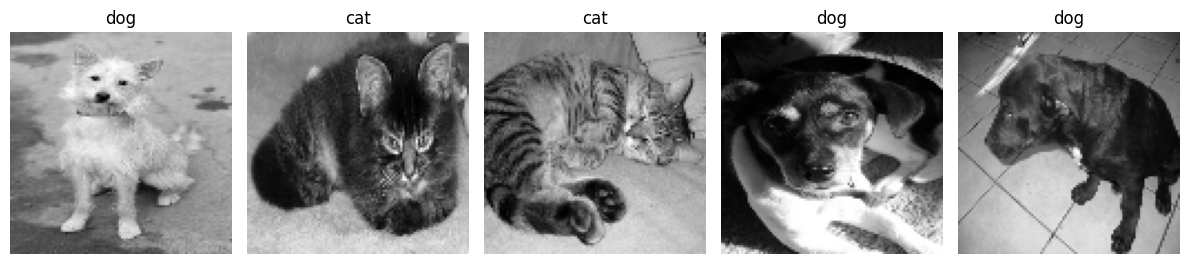

In [10]:
# Eyeball a few training images WITH their labels -- and lock in the 0/1 -> word mapping.
# WHY (look at the data): always inspect your data before training. If the
#      pictures are scrambled or the titles look wrong, fix that BEFORE wasting
#      time training.
# WHY (this is where the mapping lives): this data arrived as a pre-built pickle,
#      NOT loaded from folders named "cat"/"dog". That means the integers 0 and 1
#      carry no names with them -- the coding was decided when the pickle was
#      built and is recorded nowhere in the data. So you cannot "look up" which
#      number is the dog; you have to SEE it. (Common convention for this dataset
#      is 0 = dog, 1 = cat. VERIFIED against the preview thumbnails below:
#      thumbnail 1 is a dog and thumbnail 2 is a cat, so 0 = dog, 1 = cat is
#      correct for THIS dataset. The preview is ground truth -- if a single
#      PREDICTION later looks wrong while these titles are right, that is the
#      model being weak, not the labels (see the prediction cell).)
# HOW TO CONFIRM (do this once): run the cell and read the titles. If a picture
#      that is clearly a dog is titled "dog", the mapping is right. If a clear
#      dog is titled "cat", swap the two words in LABEL_NAMES and re-run.
# WHY IT MATTERS LATER: every later cell -- including the final prediction --
#      reads from THIS one dictionary. Fix it here and the whole notebook is
#      consistent; there is no second place to keep in sync.
# EXPECT: a row of small grayscale thumbnails titled "cat" or "dog".
LABEL_NAMES = {0: "dog", 1: "cat"}   # <-- SOURCE OF TRUTH. Flip the words if the preview titles are wrong.
N_PREVIEW = 5                        # how many sample images to show

fig, axes = plt.subplots(1, N_PREVIEW, figsize=(12, 3))
for i in range(N_PREVIEW):
    img = X[i]
    if img.shape[-1] == 1:           # grayscale stored as (H, W, 1) -> drop the trailing 1 for display
        img = img.reshape(img.shape[0], img.shape[1])
    axes[i].imshow(img, cmap="gray")
    axes[i].set_title(LABEL_NAMES.get(int(y[i]), str(int(y[i]))))   # title each thumbnail with its label word
    axes[i].axis("off")
plt.tight_layout()
plt.show()

In [11]:
# Build a small convolutional neural network (CNN).
# WHY: convolution layers learn local patterns (edges, fur, ear shapes) that
#      stack up into bigger concepts -- this layering is what makes CNNs good
#      at images. Two conv+pool blocks is plenty for a teaching example.
# NOTE: the Input shape is read straight from the data (X.shape[1:]) so this
#       cell keeps working even if the image size or channel count changes.
# EXPECT: model.summary() prints the layer stack and the parameter counts.
CONV_FILTERS = 64                    # feature maps each conv layer learns
KERNEL_SIZE = (3, 3)                 # size of the sliding window
POOL_SIZE = (2, 2)                   # halves height/width after each block
DENSE_UNITS = 64                     # neurons in the hidden dense layer
DROPOUT_RATE = 0.30                  # drop 30% of units while training (anti-overfit)

model = Sequential([
    Input(shape=X.shape[1:]),                                   # (H, W, C)
    Conv2D(CONV_FILTERS, KERNEL_SIZE, activation="relu"),
    MaxPooling2D(pool_size=POOL_SIZE),

    Conv2D(CONV_FILTERS, KERNEL_SIZE, activation="relu"),
    MaxPooling2D(pool_size=POOL_SIZE),

    Flatten(),                       # 2D feature maps -> 1D vector
    Dense(DENSE_UNITS, activation="relu"),
    Dropout(DROPOUT_RATE),
    Dense(1, activation="sigmoid"),  # one output in 0-1 = probability of "dog"
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 98, 98, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 49, 49, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 47, 47, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 33856)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,166,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,204,481 (8.41 MB)

 Trainable params: 2,204,481 (8.41 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# Tell the model HOW to learn.
# WHY: binary_crossentropy is the correct loss for a yes/no (cat/dog) label;
#      "adam" is a dependable default optimizer; tracking accuracy lets us
#      read progress in plain terms (% correct).
# EXPECT: a short confirmation line -- no heavy output here.
model.compile(optimizer="adam",
              loss="binary_crossentropy",
              metrics=["accuracy"])

print("model compiled")

model compiled


In [13]:
# Train the network.
# WHY: model.fit shows the data to the network many times (epochs); each pass
#      nudges the weights to make fewer mistakes. validation_split holds back
#      a slice of data the model never trains on, so we can tell real learning
#      apart from memorizing.
# NOTE: with only 2 epochs the model barely learns and its outputs sit near
#       0.5 -- a coin flip -- so single-image predictions are unreliable and can
#       look 'flipped'. We use 12 here so predictions are trustworthy. Watch
#       val_accuracy: raise EPOCHS while it keeps rising, stop once it plateaus
#       (more epochs after that just overfit).
# EXPECT: one line per epoch with loss falling and accuracy rising.
EPOCHS = 12                        # full passes over the training data
BATCH_SIZE = 32                      # images processed before each weight update
VALIDATION_SPLIT = 0.10              # fraction held out to watch for overfitting

history = model.fit(X, y,
                    epochs=EPOCHS,
                    batch_size=BATCH_SIZE,
                    validation_split=VALIDATION_SPLIT)

Epoch 1/12
702/702 ━━━━━━━━━━━━━━━━━━━━ 18s 19ms/step - accuracy: 0.6145 - loss: 0.6437 - val_accuracy: 0.7287 - val_loss: 0.5494
Epoch 2/12
702/702 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.7335 - loss: 0.5364 - val_accuracy: 0.7707 - val_loss: 0.4863
Epoch 3/12
702/702 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.7770 - loss: 0.4738 - val_accuracy: 0.7856 - val_loss: 0.4549
Epoch 4/12
702/702 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.8037 - loss: 0.4286 - val_accuracy: 0.7792 - val_loss: 0.4809
Epoch 5/12
702/702 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.8241 - loss: 0.3905 - val_accuracy: 0.7960 - val_loss: 0.4518
Epoch 6/12
702/702 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.8430 - loss: 0.3575 - val_accuracy: 0.8060 - val_loss: 0.4589
Epoch 7/12
702/702 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.8572 - loss: 0.3165 - val_accuracy: 0.8008 - val_loss: 0.4586
Epoch 8/12
702/702 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.8751 - loss: 0.2811 - 

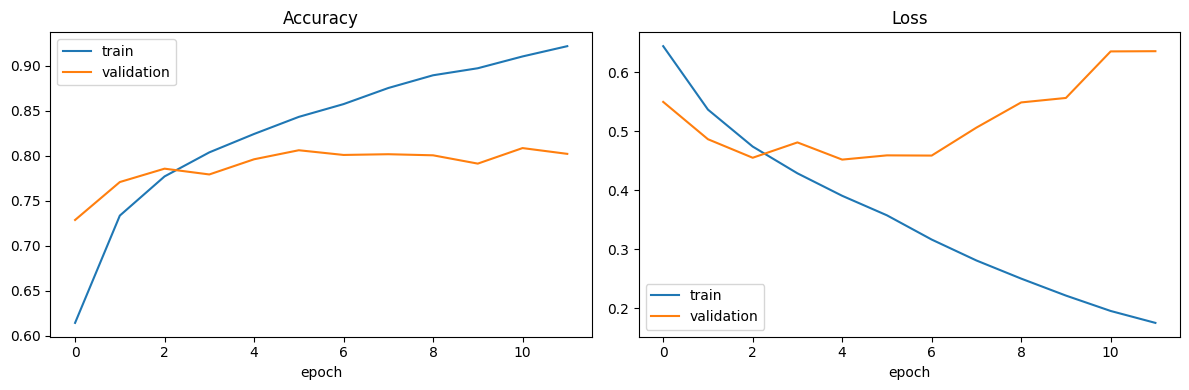

In [14]:
# Plot training vs validation accuracy and loss.
# WHY: a picture makes overfitting obvious. If the training curve keeps
#      improving while the validation curve stalls or gets worse, the model
#      is memorizing the training set instead of learning to generalize.
# EXPECT: two side-by-side line charts across the epochs.
fig, (ax_acc, ax_loss) = plt.subplots(1, 2, figsize=(12, 4))

ax_acc.plot(history.history["accuracy"], label="train")
ax_acc.plot(history.history["val_accuracy"], label="validation")
ax_acc.set_title("Accuracy")
ax_acc.set_xlabel("epoch")
ax_acc.legend()

ax_loss.plot(history.history["loss"], label="train")
ax_loss.plot(history.history["val_loss"], label="validation")
ax_loss.set_title("Loss")
ax_loss.set_xlabel("epoch")
ax_loss.legend()

plt.tight_layout()
plt.show()

## Classifying the unseen test image

The real test of a classifier is a picture it has never seen. We download `dog.jpg`, reshape it to look exactly like the training images, and ask the model what it thinks.

In [15]:
# Download the single test image the project provides.
# WHY: we want a picture the model never saw during training.
# EXPECT: a file "dog.jpg" saved in the working directory.
import urllib.request

TEST_IMAGE_URL = "https://ddc-datascience.s3.amazonaws.com/Projects/Project.6-Images/Data/dog.jpg"
TEST_IMAGE_PATH = "dog.jpg"

urllib.request.urlretrieve(TEST_IMAGE_URL, TEST_IMAGE_PATH)
print("saved:", TEST_IMAGE_PATH)

saved: dog.jpg


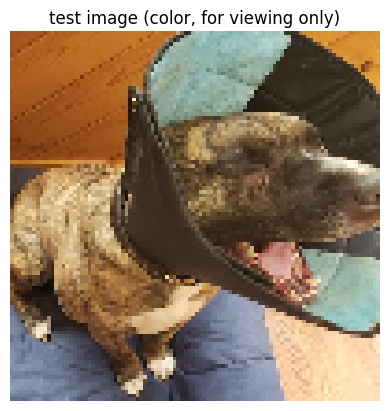

test image shape fed to model: (1, 100, 100, 1)


In [16]:
# Preprocess the test image so it looks EXACTLY like the training images.
# WHY: a model only understands inputs shaped the way it was trained on. The
#      training set is grayscale and a fixed size, so we must match both the
#      channel count and the height/width, then rescale to 0-1.
# NOTE: the size and channel count are read from the training data (X.shape),
#       so this stays correct even if the dataset changes. cv2 is used because
#       the original training images were built with cv2 (grayscale).
# EXPECT: a full-COLOR image displayed, plus a model-input shape of (1, H, W, C).
import cv2

IMG_HEIGHT = X.shape[1]
IMG_WIDTH = X.shape[2]
IMG_CHANNELS = X.shape[3]

# --- Model input: must match training (grayscale if that is what X holds) ---
read_mode = cv2.IMREAD_GRAYSCALE if IMG_CHANNELS == 1 else cv2.IMREAD_COLOR
raw = cv2.imread(TEST_IMAGE_PATH, read_mode)
resized = cv2.resize(raw, (IMG_WIDTH, IMG_HEIGHT))
test_image = resized.reshape(1, IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS) / PIXEL_MAX

# --- Display copy: always load in full color, ONLY for showing the picture ---
# WHY: the model copy above may be grayscale, which has no real color to show.
#      We re-read the same file in color so a human can see the actual photo.
#      cv2 loads channels as BGR, so we flip to RGB for matplotlib.
display_raw = cv2.imread(TEST_IMAGE_PATH, cv2.IMREAD_COLOR)
display_rgb = cv2.cvtColor(display_raw, cv2.COLOR_BGR2RGB)
display_resized = cv2.resize(display_rgb, (IMG_WIDTH, IMG_HEIGHT))

# No cmap here: cmap is ignored on 3-channel RGB data, which is what we want.
plt.imshow(display_resized)
plt.title("test image (color, for viewing only)")
plt.axis("off")
plt.show()

print("test image shape fed to model:", test_image.shape)

In [17]:
# Ask the trained model what the test image is.
# WHY (one number): the final layer is a single sigmoid neuron, so the model
#      returns ONE value between 0 and 1. That value is the probability of
#      CLASS 1 -- i.e. the probability that the image is LABEL_NAMES[1]. A 0.5
#      cutoff turns that probability into a plain yes/no decision.
# WHY (no hardcoded animal): this cell deliberately never types the words "cat"
#      or "dog". It reads them from LABEL_NAMES (set in the preview cell). That
#      is what fixes the "it said cat but the number looked like a dog" trap:
#      the probability and the prediction are now BOTH labeled from the same
#      dictionary, so they cannot disagree with each other or with the preview.
#      If the answer ever looks flipped, the fix is in the preview cell, not here.
# NOTE (read the number honestly): a probability near 0.5 means the model is
#      genuinely unsure. A small model trained for only a few epochs can also be
#      confidently WRONG on a single brand-new picture -- so a surprising call on
#      one image is normal, not necessarily a code bug.
# IMPORTANT (labels vs. training -- the trap we hit once):
#      * If the PREVIEW titles look wrong -> the LABEL_NAMES mapping is wrong; fix
#        it in the preview cell. That fixes the preview AND every prediction at once.
#      * If the preview titles are RIGHT but one PREDICTION looks wrong -> that is
#        the model being unsure/weak, NOT a label bug. The fix is more training
#        (raise EPOCHS), never re-flipping the labels. Re-flipping would only hide
#        a wrong answer behind a coincidentally-correct word.
# EXPECT: a probability and a one-word prediction printed in plain language.
DECISION_THRESHOLD = 0.50            # >= this -> class 1 (LABEL_NAMES[1]); below -> class 0 (LABEL_NAMES[0])

prob_class1 = float(model.predict(test_image)[0][0])        # P(image is LABEL_NAMES[1])
predicted_label = 1 if prob_class1 >= DECISION_THRESHOLD else 0

# Label the probability with whatever class 1 actually is, so the printout is self-explanatory.
print("probability it is", LABEL_NAMES[1], "(class 1):", round(prob_class1, 3))
print("prediction:", LABEL_NAMES[predicted_label])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 425ms/step
probability it is cat (class 1): 0.754
prediction: cat


## Classify Any Image You Upload

Everything above trained the model and tested it on the single image the project
provided. This section lets you point that **same trained model** at **any image
you choose** — a photo from your phone, a download, anything.

It works two ways automatically:

- **Google Colab** → you get a "Choose Files" button to upload pictures.
- **Plain Jupyter** → list the file paths yourself in `UPLOAD_PATHS`.

The model still only knows the two classes it was trained on (see `LABEL_NAMES`),
so it will answer with one of those two no matter what you give it.


In [18]:
# Reusable image-classification helpers.
# WHY THIS EXISTS: cells 23-25 above classified ONE provided image by hand.
#   To classify ANY image we repeat the exact same three steps -- preprocess,
#   predict, report -- so we wrap them in functions once and reuse them for
#   every upload. Six months from now: call classify_image("some_photo.jpg").
#
# WHAT EACH FUNCTION DOES:
#   preprocess_for_model(path) -> turns a photo on disk into the EXACT array the
#       model was trained on: same channel count (grayscale vs color), same
#       height/width, and pixels rescaled to 0-1. Read straight from X.shape so
#       it stays correct if the dataset ever changes.
#   load_for_display(path)     -> reads the SAME photo in full color, ONLY so a
#       human can see it. (The model copy may be grayscale with no real color.)
#   classify_image(path)       -> does both of the above, asks the model, and
#       prints the probability + a plain-language label pulled from LABEL_NAMES.
#
# DEPENDS ON (defined earlier -- run the cells above first):
#   model, X, PIXEL_MAX, LABEL_NAMES, DECISION_THRESHOLD, and cv2 / np / plt.
import cv2  # already imported earlier; repeated so this cell stands on its own


def preprocess_for_model(path):
    """Photo on disk -> (1, H, W, C) array scaled 0-1, matching the training data."""
    h, w, c = X.shape[1], X.shape[2], X.shape[3]          # shape the model expects
    read_mode = cv2.IMREAD_GRAYSCALE if c == 1 else cv2.IMREAD_COLOR
    raw = cv2.imread(path, read_mode)
    if raw is None:                                        # cv2 returns None on a bad path
        raise FileNotFoundError(f"Could not read an image at: {path}")
    resized = cv2.resize(raw, (w, h))                     # cv2 wants (width, height)
    return resized.reshape(1, h, w, c) / PIXEL_MAX         # add batch dim + rescale


def load_for_display(path):
    """Photo on disk -> full-color RGB image, for human viewing only."""
    bgr = cv2.imread(path, cv2.IMREAD_COLOR)              # cv2 loads channels as BGR
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)            # flip BGR -> RGB for matplotlib
    return cv2.resize(rgb, (X.shape[2], X.shape[1]))      # (width, height)


def classify_image(path, show=True):
    """Preprocess -> predict -> print the probability and the predicted label."""
    model_input = preprocess_for_model(path)
    # One sigmoid output = probability of CLASS 1 (= LABEL_NAMES[1]).
    prob_class1 = float(model.predict(model_input, verbose=0)[0][0])
    predicted = 1 if prob_class1 >= DECISION_THRESHOLD else 0   # 0.5 cutoff -> yes/no
    if show:
        plt.imshow(load_for_display(path))
        plt.title(f"{LABEL_NAMES[predicted]}  (p={prob_class1:.2f})")
        plt.axis("off")
        plt.show()
    print(path)
    print(f"  probability it is {LABEL_NAMES[1]} (class 1): {round(prob_class1, 3)}")
    print(f"  prediction: {LABEL_NAMES[predicted]}")
    return LABEL_NAMES[predicted], prob_class1


print("helpers ready -> classify_image('your_file.jpg')")


helpers ready -> classify_image('your_file.jpg')


Saving ishihara_test_image.jpg to ishihara_test_image.jpg


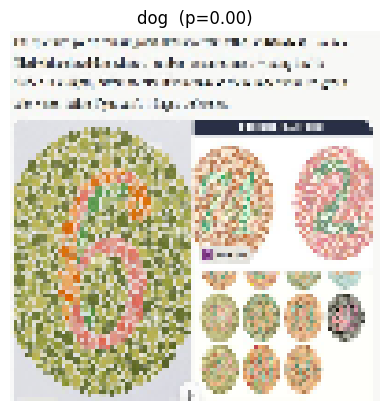

ishihara_test_image.jpg
  probability it is cat (class 1): 0.004
  prediction: dog
----------------------------------------


In [19]:
# Upload one or more images from YOUR computer, then classify each one.
# WHY: this is the actual "classify any image" step. It tries Google Colab's
#      file picker first; if you are NOT in Colab, it falls back to a list of
#      paths you fill in by hand, so the notebook still runs in plain Jupyter.
#
# HOW TO USE:
#   - In Colab:   run the cell, click "Choose Files", pick any photo(s).
#   - In Jupyter: put paths in UPLOAD_PATHS below, then run.
#
# EXPECT: each image shown with its predicted label and probability.
# REMINDER: the model has only two classes (LABEL_NAMES). Hand it a horse and it
#           will still answer cat or dog -- there is no "neither" option.
UPLOAD_PATHS = []   # <-- Jupyter fallback, e.g. ["my_cat.jpg", "/path/to/dog.png"]

paths_to_classify = []
try:
    from google.colab import files          # this import only succeeds inside Colab
    uploaded = files.upload()                # opens the browser "Choose Files" dialog
    paths_to_classify = list(uploaded.keys())  # uploads are saved to the working dir
except ModuleNotFoundError:
    paths_to_classify = UPLOAD_PATHS         # not in Colab -> use the manual list

if not paths_to_classify:
    print("No images selected.")
    print("In Colab: pick a file when prompted.")
    print("In Jupyter: add paths to UPLOAD_PATHS above, then re-run.")
else:
    for p in paths_to_classify:
        classify_image(p)
        print("-" * 40)


## Identify Any Image — General-Purpose Classifier (ImageNet)

**Why this section is separate from the cat/dog model above.** The CNN we trained
only has **two** possible answers: cat or dog. It can never say "bicycle" or
"Ishihara plate" — those categories simply do not exist inside it. So to answer
the open-ended question *"what is this image showing?"* for **any** upload, we
need a model that already knows **many** categories.

**What we use.** `MobileNetV2`, a network pre-trained by Google on **ImageNet**
(≈1.2 million photos across **1,000 everyday categories** — animals, vehicles,
foods, instruments, household objects, and so on). We download it ready-made, so
there is **no training step here**: we just feed it a picture and read back its
best guesses.

**Honest limits — important for the Ishihara example.**
- This classifier names the **overall content** of a normal photo. It is good at
  "golden retriever", "espresso", "school bus".
- It is **not** an optical-character reader and was **never** trained to read the
  hidden number inside an Ishihara color-blindness plate. Those plates are
  *designed* to hide the digit from ordinary pattern recognition, so MobileNetV2
  will likely return a vague guess (e.g., "nematode", "maze", "doily") rather
  than the number. Reading the camouflaged digit is a separate, specialized task.
- It always picks from its 1,000 known categories. Show it something outside that
  list and it will still return the closest matches — with low confidence.

So: use this to identify the *kind of thing* in any image. Treat low-confidence or
odd results as the model honestly saying "this isn't something I was taught."


In [20]:
# Load a general-purpose, pre-trained image classifier (MobileNetV2 / ImageNet).
# WHY A PRE-TRAINED MODEL: training a 1,000-category image recognizer from scratch
#   would take a huge dataset and many GPU-hours. Instead we download one Google
#   already trained. This is called "transfer of a finished model" -- we reuse
#   its learned knowledge directly, with zero training on our side.
#
# WHAT GETS DOWNLOADED: the first time this cell runs it fetches the model's
#   weights (~14 MB) over the internet and caches them, so later runs are fast.
#   In Google Colab this just works; on a locked-down machine you would need
#   internet access the first time.
#
# THREE THINGS WE IMPORT AND WHY:
#   MobileNetV2      -> the network architecture + pre-trained weights.
#   preprocess_input -> the EXACT pixel preparation MobileNetV2 expects. Every
#                       pre-trained model has its own required scaling; using the
#                       matching function is essential or predictions are garbage.
#   decode_predictions -> turns the model's 1,000 raw numbers into human-readable
#                       label names with probabilities (e.g., "tabby cat", 0.87).
#
# EXPECT: a one-time download message, then a confirmation line. The model object
#   is stored as `imagenet_model` for the cells below.
from tensorflow.keras.applications.mobilenet_v2 import (
    MobileNetV2,
    preprocess_input as imagenet_preprocess,
    decode_predictions as imagenet_decode,
)

# weights="imagenet" is what triggers the download of the trained brain.
# Without it you would get an untrained (useless) network.
imagenet_model = MobileNetV2(weights="imagenet")

# MobileNetV2 was trained on 224x224 color images, so every picture we feed it
# must be resized to this. We store it as a named constant so the intent is clear.
IMAGENET_INPUT_SIZE = (224, 224)   # (width, height) expected by the model

print("general-purpose classifier ready (MobileNetV2, 1000 ImageNet categories)")


14536120/14536120 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
general-purpose classifier ready (MobileNetV2, 1000 ImageNet categories)


In [21]:
# Reusable helper: identify what a single image is showing.
# WHY A FUNCTION: just like classify_image() for cats/dogs, wrapping the steps
#   lets us reuse them for every upload. Six months from now: identify_image("x.jpg").
#
# THE FIVE STEPS INSIDE, IN PLAIN ENGLISH:
#   1. READ the file from disk. cv2 loads color as B-G-R order...
#   2. ...so we flip it to R-G-B, the order this model (and matplotlib) expect.
#   3. RESIZE to 224x224, the only size MobileNetV2 accepts.
#   4. PREP THE PIXELS with imagenet_preprocess -- the model's own required
#      scaling. We also add a "batch" dimension so the shape is (1, 224, 224, 3),
#      because the model always expects a *stack* of images, even if it is one.
#   5. PREDICT, then DECODE the 1,000 raw scores into the top-N named guesses.
#
# RETURNS: the list of (label, probability) guesses, best first, so other code
#   could use it. Also prints them and (optionally) shows the picture.
#
# DEPENDS ON (defined above -- run the loader cell first):
#   imagenet_model, imagenet_preprocess, imagenet_decode, IMAGENET_INPUT_SIZE,
#   plus cv2 / np / plt from earlier in the notebook.
def identify_image(path, top=5, show=True):
    # 1-2. Read from disk and convert B-G-R -> R-G-B.
    bgr = cv2.imread(path, cv2.IMREAD_COLOR)
    if bgr is None:                                   # cv2 returns None on a bad path
        raise FileNotFoundError(f"Could not read an image at: {path}")
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

    # 3. Resize to the model's required 224x224.
    resized = cv2.resize(rgb, IMAGENET_INPUT_SIZE)

    # 4. Apply the model's own pixel prep, then add the batch dimension -> (1,224,224,3).
    batch = imagenet_preprocess(resized.astype("float32")[np.newaxis, ...])

    # 5. Predict (1,000 scores) and decode into the top-N human-readable guesses.
    raw_scores = imagenet_model.predict(batch, verbose=0)
    guesses = imagenet_decode(raw_scores, top=top)[0]   # list of (id, label, prob)

    if show:
        plt.imshow(rgb)                                 # show the real photo, full color
        best_label = guesses[0][1].replace("_", " ")
        best_prob = guesses[0][2]
        plt.title(f"best guess: {best_label}  ({best_prob:.1%})")
        plt.axis("off")
        plt.show()

    # Print the ranked guesses so a low top score is visible (= model is unsure).
    print(f"{path} -- top {top} guesses:")
    for _, label, prob in guesses:
        print(f"  {label.replace('_', ' '):<28} {prob:.1%}")

    # Hand back a clean (label, probability) list in case later code wants it.
    return [(label.replace("_", " "), float(prob)) for _, label, prob in guesses]


print("helper ready -> identify_image('your_file.jpg')")


helper ready -> identify_image('your_file.jpg')


Saving ishihara_test_image.jpg to ishihara_test_image (1).jpg
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step


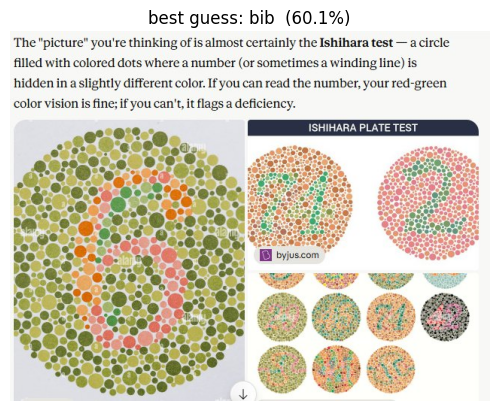

ishihara_test_image (1).jpg -- top 5 guesses:
  bib                          60.1%
  web site                     3.6%
  purse                        2.9%
  apron                        2.7%
  honeycomb                    1.6%
------------------------------------------------


In [22]:
# Upload ANY image(s) from your computer, then identify what each one shows.
# WHY: this is the open-ended "what is this picture?" step, the counterpart to the
#      cat/dog upload cell above. Same dual approach so it runs everywhere:
#        - Google Colab  -> a "Choose Files" button appears.
#        - Plain Jupyter -> list paths in IDENTIFY_PATHS below.
#
# HOW TO USE:
#   - Colab:   run, click "Choose Files", pick any photo(s) -- including the
#              Ishihara image, to see the honest limitation described above.
#   - Jupyter: put paths in IDENTIFY_PATHS, then run.
#
# EXPECT: each image shown with a ranked list of guesses and confidences.
# READING THE RESULT: a high top percentage = confident, recognizable content.
#   A low/scattered top percentage = the subject is outside the model's 1,000
#   categories (an Ishihara plate, a screenshot, abstract art, etc.).
IDENTIFY_PATHS = []   # <-- Jupyter fallback, e.g. ["ishihara.jpg", "/path/to/photo.png"]

paths_to_identify = []
try:
    from google.colab import files          # only importable inside Colab
    uploaded = files.upload()                # opens the browser file picker
    paths_to_identify = list(uploaded.keys())   # files land in the working directory
except ModuleNotFoundError:
    paths_to_identify = IDENTIFY_PATHS       # not in Colab -> use the manual list

if not paths_to_identify:
    print("No images selected.")
    print("In Colab: pick a file when prompted.")
    print("In Jupyter: add paths to IDENTIFY_PATHS above, then re-run.")
else:
    for p in paths_to_identify:
        identify_image(p)
        print("-" * 48)


## Describe Any Image in Plain Language (Image Captioning)

The ImageNet section above answers *"which of 1,000 categories is this closest
to?"* That is great for ordinary photos, but it can only ever return a single
category word, so on an unusual picture (a screenshot, a chart, an Ishihara
plate) it is forced into a vague match like "doily."

This section answers the question you actually asked — **"what is this an image
of?"** — by *describing* the picture in a short sentence instead of slotting it
into a fixed list. The tool for this is an **image-captioning model**: you give
it a picture and it **writes a caption**, e.g. *"a dog sitting in the grass"* or
*"a close up of a colorful circular pattern."*

**Model used:** `BLIP` (Salesforce), a model trained to look at an image and
generate a natural-language description. We download it ready-made — again, no
training on our side.

**Honest note on the Ishihara plate (and similar):** a captioner describes what
it *visually sees*. For an Ishihara plate it will say something accurate like
*"a colorful pattern of dots"* — a correct description of the image — but it still
will **not read the hidden number**, because the digit is deliberately
camouflaged. Describing the picture and reading a hidden figure are two different
tasks; this gives you the first, honestly.

**Heads-up on setup:** this model is larger than MobileNetV2 (a few hundred MB)
and runs on PyTorch. In Google Colab it downloads and runs fine; the **first run
takes a minute or two** while it downloads, then later runs are fast.


In [23]:
# Set up the image-captioning model (BLIP) that DESCRIBES a picture in words.
# WHY A DIFFERENT MODEL AGAIN: classification picks ONE label from a fixed list;
#   captioning GENERATES a sentence, which is what "what is this an image of?"
#   really asks for. Different job -> different model.
#
# DEPENDENCIES: BLIP runs on PyTorch via Hugging Face "transformers".
#   - Google Colab already has torch and pillow; it may or may not have
#     transformers, so we install it to be safe. The "-q" just keeps it quiet.
#   - The "!" makes this a shell command (works in Colab/Jupyter notebooks).
#   - This line is harmless to re-run: if transformers is already there, pip
#     simply confirms and moves on.
get_ipython().system('pip install -q transformers')

# Two pieces we load, and why:
#   BlipProcessor              -> turns a raw image into the exact tensors the
#                                 model expects (resizing, normalizing for us).
#   BlipForConditionalGeneration -> the actual captioning network that writes text.
from transformers import BlipProcessor, BlipForConditionalGeneration

# The specific pre-trained model to download. "base" is the smaller/faster one;
# it is plenty for describing everyday images.
CAPTION_MODEL_NAME = "Salesforce/blip-image-captioning-base"

# from_pretrained(...) downloads the model the first time, then caches it.
# EXPECT: a one-time download progress bar, then the confirmation line below.
caption_processor = BlipProcessor.from_pretrained(CAPTION_MODEL_NAME)
caption_model = BlipForConditionalGeneration.from_pretrained(CAPTION_MODEL_NAME)

print("captioning model ready -> describe_image('your_file.jpg')")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.56k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

KeyboardInterrupt: 

In [ ]:
# Reusable helper: READ an image file and SAY what it is an image of.
# WHY A FUNCTION: same reason as before -- define the steps once, reuse for every
#   upload. Six months from now: describe_image("some_photo.jpg").
#
# THE FOUR STEPS INSIDE, IN PLAIN ENGLISH:
#   1. OPEN the file as a normal RGB color image (PIL = the Python Imaging Library,
#      a.k.a. "Pillow"). .convert("RGB") guarantees 3 color channels even if the
#      file was grayscale or had transparency.
#   2. ENCODE the image into model inputs. The processor handles the resizing and
#      normalizing the model needs, so we do not do it by hand here.
#   3. GENERATE a caption. torch.no_grad() means "we are only predicting, not
#      training," which is faster and uses less memory. max_new_tokens caps the
#      sentence length so it cannot ramble.
#   4. DECODE the model's output tokens back into a human-readable sentence.
#
# RETURNS the caption string, and prints it as a plain-language answer.
#
# DEPENDS ON (run the loader cell first):
#   caption_processor, caption_model, plus plt from earlier in the notebook.
from PIL import Image            # opens image files in many formats
import torch                     # BLIP runs on PyTorch


def describe_image(path, show=True):
    # 1. Open the picture as RGB.
    image = Image.open(path).convert("RGB")

    # 2. Convert the picture into the tensors the model expects.
    inputs = caption_processor(image, return_tensors="pt")

    # 3. Ask the model to write a caption (inference only -> no_grad).
    with torch.no_grad():
        output_ids = caption_model.generate(**inputs, max_new_tokens=30)

    # 4. Turn the generated tokens back into a normal sentence.
    caption = caption_processor.decode(output_ids[0], skip_special_tokens=True).strip()

    if show:
        plt.imshow(image)
        plt.axis("off")
        # Keep the on-image title short; the full caption is printed below.
        plt.title(caption if len(caption) <= 60 else caption[:57] + "...")
        plt.show()

    print(path)
    print(f"  this image appears to show: {caption}")
    return caption


print("helper ready -> describe_image('your_file.jpg')")


In [ ]:
# Upload ANY image(s) and have the model SAY what each one is an image of.
# WHY: this is the headline feature -- read an uploaded picture and describe it
#      in plain words. Same dual approach so it runs everywhere:
#        - Google Colab  -> a "Choose Files" button appears.
#        - Plain Jupyter -> list paths in DESCRIBE_PATHS below.
#
# HOW TO USE:
#   - Colab:   run, click "Choose Files", pick any photo(s) (try the Ishihara
#              image to see the honest limitation described above).
#   - Jupyter: put paths in DESCRIBE_PATHS, then run.
#
# EXPECT: each image shown with a one-sentence description of what it depicts.
DESCRIBE_PATHS = []   # <-- Jupyter fallback, e.g. ["ishihara.jpg", "/path/to/photo.png"]

paths_to_describe = []
try:
    from google.colab import files          # only importable inside Colab
    uploaded = files.upload()                # opens the browser file picker
    paths_to_describe = list(uploaded.keys())   # files land in the working directory
except ModuleNotFoundError:
    paths_to_describe = DESCRIBE_PATHS       # not in Colab -> use the manual list

if not paths_to_describe:
    print("No images selected.")
    print("In Colab: pick a file when prompted.")
    print("In Jupyter: add paths to DESCRIBE_PATHS above, then re-run.")
else:
    for p in paths_to_describe:
        describe_image(p)
        print("-" * 48)


## Reading the Hidden Number in an Ishihara Plate (Option A: Color Separation)

This is the specialized task we scoped: not "what kind of image is this," but
"**what number is hidden inside this color-blindness plate**."

**Why ordinary OCR fails here.** Ishihara plates are *designed* so the digit and
the background have nearly the same **brightness** and differ only in **color**
(hue), along red-green confusion lines. Convert the plate to grayscale and the
number nearly vanishes — which is the whole point of the test. So we cannot read
it from brightness; we have to separate the dots **by color** first.

**The pipeline, in five moves:**
1. Convert the plate to the **CIELAB** color space and keep only the **a\*** and
   **b\*** channels — these carry color independent of brightness, which is exactly
   where the digit is hiding.
2. **Cluster** the dot colors with k-means into a few groups. The digit’s dots
   land in a different color group than the background’s dots.
3. For each color group, build a black-and-white **mask** and use **morphology**
   to merge the scattered dots into solid strokes — so a "5" looks like a 5.
4. Show every group’s mask side by side, so you can **see** which one reveals the
   number (this is the honest payoff even when step 5 struggles).
5. Run **OCR** on each mask and report any digit it reads.

**Honest limits.** This works best on a **clean, single, standard numeric**
red-green plate. It gets unreliable on phone photos, on the winding-line "trace
the path" plates, and on the special "hidden" plates. If OCR comes back empty,
the number is usually still visible in one of the mask panels — read it by eye,
or try `n_colors=4`. Feed it ONE plate per image (not a screenshot of many).


In [ ]:
# One-time setup for the Ishihara reader: the OCR engine + its Python wrapper.
# WHY: steps 1-4 of the pipeline use libraries we already have (cv2, numpy,
#      scikit-learn). Step 5 -- actually READING the cleaned-up digit -- needs an
#      Optical Character Recognition engine. "Tesseract" is the standard free one;
#      "pytesseract" is the thin Python wrapper that calls it.
#
# WHERE THIS RUNS:
#   - Google Colab / Linux: the two install lines below set everything up.
#   - Other systems: install Tesseract the way your OS expects (e.g., on a Mac,
#     "brew install tesseract"), then just "pip install pytesseract".
#
# The "!" / get_ipython().system(...) form runs a shell command from the notebook.
# These are safe to re-run; if it is already installed, the tools just confirm.
get_ipython().system('pip install -q pytesseract scikit-learn')
get_ipython().system('apt-get -qq install -y tesseract-ocr')

print("Ishihara reader setup complete.")


In [ ]:
# Reusable helper: READ the hidden number in one Ishihara plate (Option A).
# This is the color-separation pipeline described in the markdown above.
#
# ARGUMENTS:
#   path     -> the image file (ONE clean plate works best).
#   n_colors -> how many color groups to split the dots into. 3 is a good start;
#               try 4 if the digit and background are not cleanly separated.
#   show     -> draw the input plus one mask panel per color group.
#
# RETURNS: the best digit string OCR could read ("" if none).
#
# DEPENDS ON: cv2, np, plt (already imported earlier) + sklearn + pytesseract.
import cv2
import numpy as np
from sklearn.cluster import KMeans
import pytesseract

SCALE_MAX = 500   # shrink very large images so k-means stays fast


def _circular_plate_mask(h, w):
    # The plate is round but the file is square, so the corners are junk.
    # Build a True/False circle that keeps only the round plate area.
    Y, X = np.ogrid[:h, :w]
    cy, cx = h / 2.0, w / 2.0
    radius = min(h, w) / 2.0 * 0.98
    return ((X - cx) ** 2 + (Y - cy) ** 2) <= radius ** 2


def read_ishihara_number(path, n_colors=3, show=True):
    # ---- Load and right-size -------------------------------------------------
    bgr = cv2.imread(path, cv2.IMREAD_COLOR)
    if bgr is None:
        raise FileNotFoundError(f"Could not read an image at: {path}")
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    h, w = rgb.shape[:2]
    if max(h, w) > SCALE_MAX:                      # downscale big images for speed
        scale = SCALE_MAX / max(h, w)
        rgb = cv2.resize(rgb, (int(w * scale), int(h * scale)))
        h, w = rgb.shape[:2]

    # ---- STEP 1: keep COLOR, drop brightness --------------------------------
    # CIELAB splits an image into L* (lightness) and a*, b* (color). We throw away
    # L* on purpose -- brightness is where the plate hides the digit FROM us. The
    # a*/b* color channels are where the digit hides IN PLAIN SIGHT for the math.
    lab = cv2.cvtColor(rgb, cv2.COLOR_RGB2LAB)
    ab = lab[:, :, 1:3].reshape(-1, 2).astype(np.float32)

    # ---- STEP 2: cluster the dot colors -------------------------------------
    # k-means groups every pixel into n_colors color families. The digit's dots
    # and the background's dots fall into different families.
    km = KMeans(n_clusters=n_colors, n_init=10, random_state=42).fit(ab)
    cluster_of_pixel = km.labels_.reshape(h, w)

    plate = _circular_plate_mask(h, w)
    close_k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))

    masks, readings = [], []
    for c in range(n_colors):
        # ---- STEP 3: one color group -> a cleaned black/white mask ----------
        raw = ((cluster_of_pixel == c) & plate).astype(np.uint8) * 255
        # "Close" fills the gaps between dots so they fuse into solid strokes;
        # "open" then removes leftover specks. Result: a readable glyph shape.
        merged = cv2.morphologyEx(raw, cv2.MORPH_CLOSE, close_k, iterations=2)
        merged = cv2.morphologyEx(merged, cv2.MORPH_OPEN, close_k, iterations=1)
        masks.append(merged)

        # ---- STEP 5: OCR this mask ------------------------------------------
        # Tesseract expects DARK text on a LIGHT background, so we invert. psm 8 =
        # "treat as a single word"; the whitelist forces digit-only answers.
        ocr_input = cv2.bitwise_not(merged)
        text = pytesseract.image_to_string(
            ocr_input,
            config="--psm 8 -c tessedit_char_whitelist=0123456789",
        )
        digits = "".join(ch for ch in text if ch.isdigit())
        readings.append(digits)

    # ---- STEP 4: show every mask so a human can confirm ---------------------
    if show:
        fig, axes = plt.subplots(1, n_colors + 1, figsize=(4 * (n_colors + 1), 4))
        axes[0].imshow(rgb); axes[0].set_title("input plate"); axes[0].axis("off")
        for c in range(n_colors):
            axes[c + 1].imshow(masks[c], cmap="gray")
            axes[c + 1].set_title(f"color group {c}\nOCR read: {readings[c] or '—'}")
            axes[c + 1].axis("off")
        plt.tight_layout(); plt.show()

    # ---- Decide on an answer ------------------------------------------------
    found = [d for d in readings if d]
    best = found[0] if found else ""
    print(path)
    if best:
        print(f"  best read of the hidden number: {best}")
    else:
        print("  no digit confidently read by OCR.")
        print("  The number is usually still visible in ONE of the mask panels")
        print("  above -- read it by eye, try n_colors=4, or use a cleaner scan.")
    return best


print("helper ready -> read_ishihara_number('plate.jpg', n_colors=3)")


In [ ]:
# Upload ONE Ishihara plate at a time and read its hidden number.
# WHY one-at-a-time: the pipeline isolates the single digit in the middle of one
#      round plate. A screenshot of many plates (or a plate plus text) gives the
#      color-clustering nothing clean to lock onto.
#
# HOW TO USE:
#   - Colab:   run, click "Choose Files", pick ONE clean plate image.
#   - Jupyter: put a path in ISHIHARA_PATHS below, then run.
#
# EXPECT: the input plate plus a row of color-group masks; the number should be
#         legible in one of them, and OCR's best guess is printed underneath.
ISHIHARA_PATHS = []   # <-- Jupyter fallback, e.g. ["plate_5.jpg"]
N_COLORS = 3          # bump to 4 if the digit and background do not separate cleanly

paths = []
try:
    from google.colab import files
    uploaded = files.upload()
    paths = list(uploaded.keys())
except ModuleNotFoundError:
    paths = ISHIHARA_PATHS

if not paths:
    print("No plate selected.")
    print("In Colab: pick ONE clean plate image when prompted.")
    print("In Jupyter: add a path to ISHIHARA_PATHS above, then re-run.")
else:
    for p in paths:
        read_ishihara_number(p, n_colors=N_COLORS)
        print("-" * 48)


---

Vernon T. Cox · Data Science Student, CNM · GitHub: santed7